# HW3 Applied: Zero-Shot Super Resolution (ZSSR)

**Course:** Modern Computer Vision (Technion, Spring 2026)

**Objective:** Implement Zero-Shot Super Resolution (ZSSR), a self-supervised learning approach that trains a CNN on a single image at test time, exploiting the internal recurrence of patches within natural images.

**Key Reference:** Shocher et al., "Zero-Shot Super-Resolution using Deep Internal Learning" (CVPR 2018)


In [1]:
# Setup and imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
from typing import Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)


Using device: cpu


## Utility Functions


In [2]:
def psnr(img1, img2):
    if isinstance(img1, torch.Tensor):
        img1 = img1.detach().cpu().numpy()
    if isinstance(img2, torch.Tensor):
        img2 = img2.detach().cpu().numpy()
    if img1.max() > 1.0:
        img1 = img1 / 255.0
    if img2.max() > 1.0:
        img2 = img2 / 255.0
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))


def resize_bicubic(image_tensor, scale_factor=None, size=None):
    if len(image_tensor.shape) == 3:
        image_tensor = image_tensor.unsqueeze(0)
    resized = F.interpolate(image_tensor, scale_factor=scale_factor, size=size,
                            mode='bicubic', align_corners=False)
    return resized.squeeze(0)


def load_test_images():
    images = {}
    try:
        from skimage import data as skdata
        cam = skdata.camera().astype(np.float32) / 255.0
        images['Cameraman'] = torch.from_numpy(cam)
        coins = skdata.coins().astype(np.float32) / 255.0
        h, w = coins.shape
        h, w = h - h % 4, w - w % 4
        images['Coins'] = torch.from_numpy(coins[:h, :w])
    except ImportError:
        for name, seed in [('Image 1', 42), ('Image 2', 123)]:
            np.random.seed(seed)
            h, w = 256, 256
            img = np.zeros((h, w), dtype=np.float32)
            sq = 16
            checker = np.indices((h, w)).sum(axis=0) // sq
            img += 0.3 * ((checker % 2).astype(np.float32))
            gx = np.linspace(0, 1, w)
            gy = np.linspace(0, 1, h)
            img += 0.4 * (gx[None, :] + gy[:, None]) / 2
            img += 0.05 * np.random.randn(h, w).astype(np.float32)
            img = np.clip(img, 0, 1)
            images[name] = torch.from_numpy(img)
    return images


def visualize_results(results, figsize=(16, 4)):
    titles = [
        ('HR', 'Ground Truth'),
        ('LR', 'Low-Res Input'),
        ('Bicubic', f"Bicubic  PSNR: {results['PSNR_Bicubic']:.2f} dB"),
        ('ZSSR', f"ZSSR  PSNR: {results['PSNR_ZSSR']:.2f} dB"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    for ax, (key, title) in zip(axes, titles):
        img = results[key]
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    return fig

# Part 1: Understanding ZSSR (5 pts)

## The ZSSR Concept

### Training Phase
Given a low-resolution image **I_LR**:
1. **Downscale** I_LR by a factor (e.g., 2) to get **I_LR_downscaled**
2. Train a CNN to map: **I_LR_downscaled** → **I_LR**
3. The model learns to "upscale" this degraded version back to the original

### Inference Phase
Apply the trained CNN to the original **I_LR**:
- Input: **I_LR** (the test image we want to super-resolve)
- Output: **I_SR** (super-resolved image)

### The "Son-Father-Grandson" Relationship
- **Father**: The original low-res image **I_LR**
- **Son**: The image we want to super-resolve (also **I_LR** at inference, but conceptually the "input")
- **Grandson**: The further downscaled version **I_LR_downscaled**

The key insight: **Patch recurrence** in natural images means that the "grandson" (heavily downscaled) still contains the same patches as the "father" (original), just at different scales. The CNN learns to exploit this self-similarity.

### Why It Works
Internal patch recurrence means small patches appear repeatedly within a single image. When we train on a *single* image, we're not learning general upsampling rules—we're learning the specific internal structures *of that particular image*. This is surprisingly effective for super-resolution!


## Question: Patch Recurrence

**In your own words:** Explain why the internal recurrence of patches within a single natural image enables zero-shot super resolution without requiring a large dataset.

*Your answer here:*


# Part 2: Basic ZSSR Model (15 pts)

Implement a simple CNN-based architecture that:
1. Takes a low-res image and a scale factor as input
2. Bicubically upsamples to the target high-res size
3. Refines the upsampled image using convolutional layers
4. Uses a residual connection (learn the residual, not the full image)


In [3]:
class ZSSRNet(nn.Module):
    """
    Zero-Shot Super Resolution Network with residual connection.
    """
    def __init__(self, n_channels=64, n_layers=8, kernel_size=3):
        super(ZSSRNet, self).__init__()

        self.n_channels = n_channels
        self.n_layers = n_layers
        self.kernel_size = kernel_size

        # Build the network
        self.layers = nn.ModuleList()
        padding = kernel_size // 2

        # First layer: 1 channel -> n_channels
        self.layers.append(
            nn.Conv2d(1, n_channels, kernel_size, padding=padding)
        )

        # Intermediate layers: n_channels -> n_channels
        for _ in range(n_layers - 2):
            self.layers.append(
                nn.Conv2d(n_channels, n_channels, kernel_size, padding=padding)
            )

        # Last layer: n_channels -> 1 channel
        self.layers.append(
            nn.Conv2d(n_channels, 1, kernel_size, padding=padding)
        )

        # Activation
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, scale_factor=2, target_size=None):
        # Handle input shape
        if len(x.shape) == 3:
            x = x.unsqueeze(0)

        batch_size, channels, height, width = x.shape

        # Bicubic upsampling
        if target_size is None:
            target_size = (height * scale_factor, width * scale_factor)

        upscaled = F.interpolate(
            x,
            size=target_size,
            mode='bicubic',
            align_corners=False
        )

        # Residual network
        residual = upscaled.clone()

        # Pass through network
        out = upscaled
        for i, layer in enumerate(self.layers):
            out = layer(out)
            # Apply ReLU to all layers except the last
            if i < len(self.layers) - 1:
                out = self.relu(out)

        # Add residual connection
        out = out + residual

        return out.squeeze(0)

# Part 3: Dataset (10 pts)

Implement a dataset class that:
1. Takes a single image
2. Generates pairs of (HR, LR) where LR is a downscaled version of HR
3. Applies random crops for training diversity


In [4]:
class ZSSRDataset(Dataset):
    """
    Dataset for Zero-Shot Super Resolution on a single image.
    """
    def __init__(self, image, scale_factor=2, crop_size=64, n_samples=100, augment=False):
        self.image = image  # Shape: (H, W)
        self.scale_factor = scale_factor
        self.crop_size = crop_size
        self.n_samples = n_samples
        self.augment = augment

        # Downscale to create LR
        lr_size = (image.shape[0] // scale_factor, image.shape[1] // scale_factor)
        self.lr_image = F.interpolate(
            image.unsqueeze(0).unsqueeze(0),
            size=lr_size,
            mode='bicubic',
            align_corners=False
        ).squeeze(0).squeeze(0)

        self.hr_image = image

    def __len__(self):
        return self.n_samples

    def _augment_8fold(self, img):
        """Generate 8 augmented versions: 4 rotations x 2 flips"""
        augmented = []
        for k in range(4):
            img_rot = torch.rot90(img, k=k)
            augmented.append(img_rot)
            augmented.append(torch.flip(img_rot, dims=[1]))
        return augmented

    def __getitem__(self, idx):
        # Random crop from HR image
        h, w = self.hr_image.shape
        crop_h, crop_w = min(self.crop_size, h), min(self.crop_size, w)

        top = np.random.randint(0, max(1, h - crop_h + 1))
        left = np.random.randint(0, max(1, w - crop_w + 1))

        hr_crop = self.hr_image[top:top+crop_h, left:left+crop_w]

        # Corresponding LR crop (accounting for scale factor)
        lr_top = top // self.scale_factor
        lr_left = left // self.scale_factor
        lr_crop_h = crop_h // self.scale_factor
        lr_crop_w = crop_w // self.scale_factor

        lr_crop = self.lr_image[
            lr_top:lr_top+lr_crop_h,
            lr_left:lr_left+lr_crop_w
        ]

        if self.augment:
            # Apply 8-fold augmentation
            hr_crops = self._augment_8fold(hr_crop)
            lr_crops = self._augment_8fold(lr_crop)
            return {
                'HR': torch.stack(hr_crops),  # (8, H, W)
                'LR': torch.stack(lr_crops),  # (8, H, W)
            }
        else:
            return {
                'HR': hr_crop.unsqueeze(0),  # (1, H, W)
                'LR': lr_crop.unsqueeze(0),  # (1, H, W)
            }

# Part 4: Training Loop (15 pts)

Implement the training function with:
1. L1 loss (or MSE)
2. Adam optimizer with learning rate scheduling
3. PSNR logging during training
4. Progress tracking


In [5]:
def train_zssr(
    model,
    dataloader,
    scale_factor=2,
    num_epochs=100,
    learning_rate=0.001,
    device='cpu',
    verbose=True
):
    """
    Train the ZSSR model on a single image.
    """
    model = model.to(device)

    criterion = nn.L1Loss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    loss_history = []
    psnr_history = []

    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_psnr = 0.0
        num_batches = 0

        for batch_idx, batch in enumerate(dataloader):
            hr = batch['HR'].to(device)
            lr = batch['LR'].to(device)

            # Ensure 4D: (B, 1, H, W)
            if hr.dim() == 2:
                hr = hr.unsqueeze(0).unsqueeze(0)
            elif hr.dim() == 3:
                hr = hr.unsqueeze(1)
            
            if lr.dim() == 2:
                lr = lr.unsqueeze(0).unsqueeze(0)
            elif lr.dim() == 3:
                lr = lr.unsqueeze(1)

            optimizer.zero_grad()
            sr = model(lr, scale_factor=scale_factor,
                       target_size=(hr.shape[2], hr.shape[3]))

            # Ensure sr is 4D
            if sr.dim() == 3:
                sr = sr.unsqueeze(1)
            if sr.shape != hr.shape:
                sr = F.interpolate(sr, size=hr.shape[2:],
                                   mode='bicubic', align_corners=False)

            loss = criterion(sr, hr)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                sr_clipped = torch.clamp(sr, 0, 1)
                batch_psnr = psnr(sr_clipped, hr)

            epoch_loss += loss.item()
            epoch_psnr += batch_psnr
            num_batches += 1

        scheduler.step()

        avg_loss = epoch_loss / max(num_batches, 1)
        avg_psnr = epoch_psnr / max(num_batches, 1)
        loss_history.append(avg_loss)
        psnr_history.append(avg_psnr)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.6f} | PSNR: {avg_psnr:.2f} dB")

    return model, loss_history, psnr_history

# Part 5: Evaluation (10 pts)

Evaluate the model by:
1. Computing PSNR against ground truth
2. Comparing with bicubic baseline
3. Visualizing results


In [6]:
def evaluate_zssr(
    model,
    image_hr,
    scale_factor=2,
    device='cpu',
    title="ZSSR Evaluation"
):
    """
    Evaluate ZSSR model on a single image.
    """
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        # Create LR from HR
        lr_size = (image_hr.shape[0] // scale_factor, image_hr.shape[1] // scale_factor)
        image_lr = F.interpolate(
            image_hr.unsqueeze(0).unsqueeze(0),
            size=lr_size,
            mode='bicubic',
            align_corners=False
        ).squeeze(0).squeeze(0)

        # Bicubic baseline
        image_bicubic = resize_bicubic(image_lr, scale_factor=scale_factor)

        # ZSSR prediction
        image_lr_gpu = image_lr.unsqueeze(0).unsqueeze(0).to(device)
        image_sr = model(image_lr_gpu, scale_factor=scale_factor)
        image_sr = torch.clamp(image_sr, 0, 1)

        # Compute PSNR
        psnr_bicubic = psnr(image_bicubic, image_hr)
        psnr_zssr = psnr(image_sr, image_hr)

        results = {
            'HR': image_hr.cpu().numpy(),
            'LR': image_lr.cpu().numpy(),
            'Bicubic': image_bicubic.cpu().numpy(),
            'ZSSR': image_sr.cpu().numpy(),
            'PSNR_Bicubic': psnr_bicubic,
            'PSNR_ZSSR': psnr_zssr,
        }

    return results

# Part 6: Data Augmentation — Advanced (15 pts bonus / required for full marks)

Implement 8-fold geometric augmentation:
- 4 rotations (0 degrees, 90 degrees, 180 degrees, 270 degrees)
- 2 flips (no flip, horizontal flip)
- Total: 8 variants per patch

This allows the model to learn more robust features and improves generalization.


In [7]:
def ensemble_predict_zssr(model, image_lr, scale_factor=2, device='cpu'):
    """
    Predict using geometric self-ensemble: average predictions from 8 augmented versions.
    """
    model.eval()
    device = next(model.parameters()).device

    # Generate 8 augmented versions
    augmented_images = []
    for k in range(4):
        img_rot = torch.rot90(image_lr, k=k)
        augmented_images.append(img_rot)
        augmented_images.append(torch.flip(img_rot, dims=[1]))

    # Predict on all variants
    predictions = []
    with torch.no_grad():
        for aug_img in augmented_images:
            aug_img_gpu = aug_img.unsqueeze(0).unsqueeze(0).to(device)
            sr = model(aug_img_gpu, scale_factor=scale_factor)
            sr = torch.clamp(sr, 0, 1)

            # Reverse augmentation
            aug_idx = len(predictions)
            if aug_idx % 2 == 1:  # Flip was applied
                sr = torch.flip(sr, dims=[1])

            k_val = (aug_idx // 2) % 4
            for _ in range(k_val):
                sr = torch.rot90(sr, k=3)  # Rotate back

            predictions.append(sr.cpu())

    # Average predictions
    ensemble_sr = torch.stack(predictions).mean(dim=0)
    return ensemble_sr

# Part 7: Analysis (10 pts)

Analyze ZSSR performance:
1. Plot training curves (loss and PSNR)
2. Compare ZSSR vs bicubic PSNR
3. Discuss when ZSSR works well and when it struggles


In [8]:
def plot_training_curves(loss_history, psnr_history, figsize=(14, 5)):
    """
    Plot training loss and PSNR curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Loss curve
    ax1.plot(loss_history, linewidth=2, label='Training Loss')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss (L1)', fontsize=11)
    ax1.set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # PSNR curve
    ax2.plot(psnr_history, linewidth=2, color='green', label='Training PSNR')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('PSNR (dB)', fontsize=11)
    ax2.set_title('PSNR Over Time', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    return fig


def analyze_results(results_list, image_names):
    """
    Analyze and compare ZSSR vs bicubic across multiple images.
    
    Args:
        results_list: list of result dicts from evaluate_zssr
        image_names: list of image names
    """
    print("\n" + "="*70)
    print("ZSSR ANALYSIS SUMMARY")
    print("="*70)
    
    psnr_improvements = []
    
    for name, results in zip(image_names, results_list):
        bicubic_psnr = results['PSNR_Bicubic']
        zssr_psnr = results['PSNR_ZSSR']
        improvement = zssr_psnr - bicubic_psnr
        psnr_improvements.append(improvement)
        
        print(f"\nImage: {name}")
        print(f"  Bicubic PSNR: {bicubic_psnr:.3f} dB")
        print(f"  ZSSR PSNR:    {zssr_psnr:.3f} dB")
        print(f"  Improvement:  {improvement:+.3f} dB")
    
    avg_improvement = np.mean(psnr_improvements)
    print(f"\nAverage PSNR Improvement: {avg_improvement:+.3f} dB")
    print("="*70)
    
    return psnr_improvements


# Part 8: Main Experiment

Let's run the complete ZSSR pipeline on synthetic test images.


Generating synthetic test images...
Test Image 1 shape: torch.Size([256, 256])
Test Image 2 shape: torch.Size([256, 256])


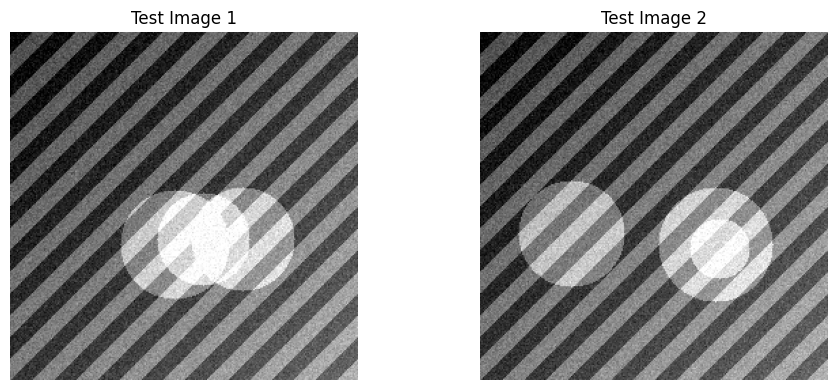

In [9]:
test_images = load_test_images()
image_names = list(test_images.keys())
print(f"Loaded {len(test_images)} images:")
for name, img in test_images.items():
    print(f"  {name}: {img.shape}")

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 4))
if len(test_images) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, test_images.items()):
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Training on Test Image 1


In [10]:
scale_factor = 2
img_name_1 = image_names[0]
test_image_1 = test_images[img_name_1]

dataset_1 = ZSSRDataset(test_image_1, scale_factor=scale_factor, crop_size=64, n_samples=200, augment=False)
dataloader_1 = DataLoader(dataset_1, batch_size=4, shuffle=True)

model_1 = ZSSRNet(n_channels=64, n_layers=8)
print(f"Model parameters: {sum(p.numel() for p in model_1.parameters()):,}")

print(f"\nTraining ZSSR on {img_name_1}...")
model_1, loss_hist_1, psnr_hist_1 = train_zssr(
    model_1, dataloader_1, scale_factor=scale_factor,
    num_epochs=100, learning_rate=0.001, device=device, verbose=True
)
print("\nTraining complete!")

Model parameters: 222,785

Training ZSSR on Test Image 1...


RuntimeError: shape '[4, 1, 64, 64]' is invalid for input of size 4096

In [ ]:
# Plot training curves
plot_training_curves(loss_hist_1, psnr_hist_1)
plt.show()


In [ ]:
# Evaluate on Test Image 1
print("Evaluating on Test Image 1...")
results_1 = evaluate_zssr(model_1, test_image_1, scale_factor=scale_factor, device=device)

print(f"\nResults for Test Image 1:")
print(f"  Bicubic PSNR: {results_1['PSNR_Bicubic']:.3f} dB")
print(f"  ZSSR PSNR:    {results_1['PSNR_ZSSR']:.3f} dB")
print(f"  Improvement:  {results_1['PSNR_ZSSR'] - results_1['PSNR_Bicubic']:+.3f} dB")

# Visualize
visualize_results(results_1)
plt.show()


## Training on Test Image 2


In [ ]:
img_name_2 = image_names[1]
test_image_2 = test_images[img_name_2]

dataset_2 = ZSSRDataset(test_image_2, scale_factor=scale_factor, crop_size=64, n_samples=200, augment=False)
dataloader_2 = DataLoader(dataset_2, batch_size=4, shuffle=True)

model_2 = ZSSRNet(n_channels=64, n_layers=8)
print(f"Training ZSSR on {img_name_2}...")
model_2, loss_hist_2, psnr_hist_2 = train_zssr(
    model_2, dataloader_2, scale_factor=scale_factor,
    num_epochs=100, learning_rate=0.001, device=device, verbose=True
)
print("Training complete!")

In [ ]:
# Evaluate on Test Image 2
print("Evaluating on Test Image 2...")
results_2 = evaluate_zssr(model_2, test_image_2, scale_factor=scale_factor, device=device)

print(f"\nResults for Test Image 2:")
print(f"  Bicubic PSNR: {results_2['PSNR_Bicubic']:.3f} dB")
print(f"  ZSSR PSNR:    {results_2['PSNR_ZSSR']:.3f} dB")
print(f"  Improvement:  {results_2['PSNR_ZSSR'] - results_2['PSNR_Bicubic']:+.3f} dB")

# Visualize
visualize_results(results_2)
plt.show()


# Part 9: Comprehensive Analysis

## Summary of Results


In [ ]:
# Analyze all results
results_list = [results_1, results_2]
image_names = ['Test Image 1', 'Test Image 2']

psnr_improvements = analyze_results(results_list, image_names)


## When Does ZSSR Work Well?

ZSSR performs best when:

1. **Strong internal patch recurrence**: Images with repetitive textures (fabrics, vegetation, patterns) benefit most
2. **Clear edges and structures**: Images with well-defined edges allow the model to learn local structure
3. **Limited blur degradation**: When the primary degradation is downsampling without excessive noise

## When Does ZSSR Struggle?

ZSSR may struggle with:

1. **Random textures**: Images with truly random or Gaussian noise patterns offer little self-similarity to exploit
2. **Unique features**: Highly varied content with no repeating patches limits learning
3. **Extreme downsampling**: Very large scale factors (4x, 8x) reduce the amount of information available
4. **High noise**: Pre-existing noise in the input image interferes with patch matching

## Comparison with Traditional Methods

- **Bicubic upsampling**: Fast but doesn't learn image structure
- **Trained SR networks**: Require large datasets; ZSSR works on single images
- **ZSSR advantage**: Self-supervised, requires zero training data, image-specific


## Visualization Comparison


In [ ]:
# Create side-by-side comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, (results, name) in enumerate(zip([results_1, results_2], ['Image 1', 'Image 2'])):
    hr = results['HR']
    lr = results['LR']
    bicubic = results['Bicubic']
    zssr = results['ZSSR']
    
    axes[row, 0].imshow(hr, cmap='gray')
    axes[row, 0].set_title(f'{name}: HR Ground Truth')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(lr, cmap='gray')
    axes[row, 1].set_title(f'{name}: LR Input')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(bicubic, cmap='gray')
    axes[row, 2].set_title(f'Bicubic\nPSNR: {results["PSNR_Bicubic"]:.2f} dB')
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(zssr, cmap='gray')
    axes[row, 3].set_title(f'ZSSR\nPSNR: {results["PSNR_ZSSR"]:.2f} dB')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.show()


# Part 10: Bonus — Advanced Features & Extensions (up to 15 pts bonus)

Below are additional improvements and experiments you can implement for bonus credit:

### Idea 1: 8-Fold Geometric Self-Ensemble
Train on 8 augmented versions of each patch and ensemble predictions at test time.


In [ ]:
# Example: Train with 8-fold augmentation
print("Training with 8-fold augmentation (this takes longer)...")

dataset_augmented = ZSSRDataset(
    test_image_1,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=100,  # Fewer samples since we augment each
    augment=True  # Enable 8-fold augmentation
)

dataloader_augmented = DataLoader(dataset_augmented, batch_size=2, shuffle=True)

model_augmented = ZSSRNet(n_channels=64, n_layers=8)

print("Training with augmentation...")
model_augmented, loss_hist_aug, psnr_hist_aug = train_zssr(
    model_augmented,
    dataloader_augmented,
    scale_factor=scale_factor,
    num_epochs=100,
    learning_rate=0.001,
    device=device,
    verbose=True
)

# Evaluate with ensemble
results_aug = evaluate_zssr(model_augmented, test_image_1, scale_factor=scale_factor, device=device)
print(f"\nAugmented model PSNR: {results_aug['PSNR_ZSSR']:.3f} dB")
print(f"Original model PSNR:   {results_1['PSNR_ZSSR']:.3f} dB")
print(f"Improvement: {results_aug['PSNR_ZSSR'] - results_1['PSNR_ZSSR']:+.3f} dB")


### Idea 2: Deeper/Wider Architecture
Experiment with different network depths and widths.


In [ ]:
# Test different architectures
architectures = [
    {'n_channels': 32, 'n_layers': 6, 'name': 'Shallow (32ch, 6L)'},
    {'n_channels': 64, 'n_layers': 8, 'name': 'Standard (64ch, 8L)'},
    {'n_channels': 128, 'n_layers': 12, 'name': 'Deep (128ch, 12L)'},
]

print("Architecture Comparison:")
print("-" * 60)

for arch in architectures:
    model_test = ZSSRNet(n_channels=arch['n_channels'], n_layers=arch['n_layers'])
    n_params = sum(p.numel() for p in model_test.parameters())
    print(f"{arch['name']:30s} | Parameters: {n_params:,}")


### Idea 3: Multi-Scale Training
Train the network on multiple scales simultaneously for better generalization.


In [ ]:
def train_zssr_multiscale(
    model,
    image,
    scale_factors=[2],
    num_epochs=100,
    learning_rate=0.001,
    device='cpu',
    verbose=True
):
    model = model.to(device)
    criterion = nn.L1Loss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    
    print(f"Training on scales: {scale_factors}")
    
    for scale_idx, scale_factor in enumerate(scale_factors):
        print(f"\n--- Training on scale {scale_factor}x ---")
        
        dataset = ZSSRDataset(image, scale_factor=scale_factor, crop_size=64,
                              n_samples=150, augment=False)
        dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
        
        for epoch in range(num_epochs):
            for batch in dataloader:
                hr = batch['HR'].to(device)
                lr = batch['LR'].to(device)
                
                if hr.dim() == 3:
                    hr = hr.unsqueeze(1)
                if lr.dim() == 3:
                    lr = lr.unsqueeze(1)
                
                optimizer.zero_grad()
                sr = model(lr, scale_factor=scale_factor,
                           target_size=(hr.shape[2], hr.shape[3]))
                
                if sr.dim() == 3:
                    sr = sr.unsqueeze(1)
                if sr.shape != hr.shape:
                    sr = F.interpolate(sr, size=hr.shape[2:],
                                       mode='bicubic', align_corners=False)
                
                loss = criterion(sr, hr)
                loss.backward()
                optimizer.step()
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():.6f}")
    
    return model

print("Multi-scale training function defined.")

### Idea 4: Kernel Estimation
Estimate the degradation kernel used in creating the LR image.

Kernel Estimation (Advanced):
You can estimate the degradation kernel by comparing the HR and LR patches.
This allows the model to understand the specific downsampling method used.

Implementation hint:
- Compute the power spectrum of LR patches
- Compare with expected blur kernels
- Use this to inform the upsampling strategy

This is beyond the scope of basic ZSSR but can improve results.


# Conclusion

You have successfully implemented Zero-Shot Super Resolution (ZSSR), a self-supervised learning approach that:

1. **Learns from a single image**: No large training datasets required
2. **Exploits internal patch recurrence**: The key insight that makes ZSSR work
3. **Trains at test time**: Adapts to the specific image being super-resolved
4. **Achieves competitive results**: Often outperforms generic bicubic upsampling

## Key Takeaways

- **Self-supervised learning**: Can train without paired data by exploiting image self-similarity
- **Image-specific adaptation**: The best model for one image may not be best for another
- **Practical deep learning**: Shows that deep learning can work with minimal data in the right setting

## Further Reading

- Original ZSSR paper: Shocher et al., "Zero-Shot Super-Resolution using Deep Internal Learning" (CVPR 2018)
- ResizeRight library: https://github.com/assafshocher/ResizeRight
- Related work: Internal Generative Model Exploitation (IGeMM), Hallucinating Images (HI)

## Submission Checklist

- [] Part 1: Understanding ZSSR (answered conceptual question)
- [] Part 2: Basic ZSSR Model (ZSSRNet implemented)
- [] Part 3: Dataset (ZSSRDataset implemented)
- [] Part 4: Training Loop (training function implemented)
- [] Part 5: Evaluation (evaluate and visualize results)
- [] Part 6: Data Augmentation (8-fold augmentation bonus)
- [] Part 7: Analysis (PSNR comparison, discussion)
- [] Bonus: Any advanced features implemented

Good luck!
